In [1]:
from pathlib import Path
import pickle
import pandas as pd
from scipy.signal import savgol_filter


def load_logs_to_dataframe(
    base_path,
    algorithms,
    seeds,
    filename_prefix="fr3_pusht_",
):
    """
    Sweep over algorithms and seeds, load log pickles, and return a single
    pandas.DataFrame with extra columns 'algorithm' and 'seed'.

    Parameters
    ----------
    base_path : str or Path
        Directory in which the .pkl files are stored.
    algorithms : iterable
        Iterable of controller classes (or names). If controller classes
        are passed, their __name__ attribute is used.
    seeds : iterable
        Iterable of int seeds to sweep over.
    filename_prefix : str
        Prefix used when saving: f"{prefix}{ctrl.__class__.__name__}_seed{seed}.pkl"

    Returns
    -------
    df : pd.DataFrame
        Concatenated dataframe of all logs that were found.
    """
    base_path = Path(base_path)
    all_dfs = []

    for algo in algorithms:
        # Allow passing in classes or plain strings
        algo_name = algo.__name__ if hasattr(algo, "__name__") else str(algo)

        for seed in seeds:
            log_file = base_path / f"{filename_prefix}{algo_name}_seed{seed}.pkl"
            if not log_file.exists():
                # Skip silently or log a warning, depending on your preference
                continue

            with open(log_file, "rb") as f:
                log_list = pickle.load(f)

            # log_list is your self.log: a list of dicts
            df = pd.DataFrame(log_list)
            df["algorithm"] = algo_name
            df["seed"] = seed
            all_dfs.append(df)

    if not all_dfs:
        # Return empty dataframe with no rows if nothing found
        return pd.DataFrame()

    return pd.concat(all_dfs, ignore_index=True)


CEM mean final error: 4.3042 ± 0.0000
MTP mean final error: 0.4628 ± 0.0000
MPPI mean final error: 1.2965 ± 0.0000


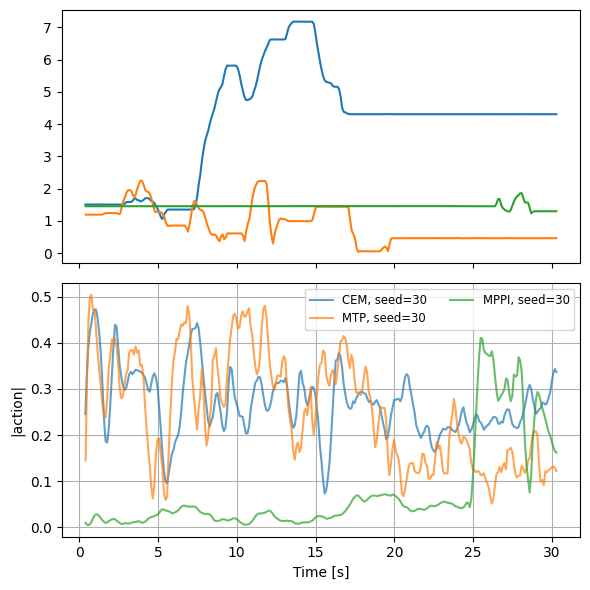

<Figure size 640x480 with 0 Axes>

In [2]:
from hydrax.utils.files import get_data_path

import matplotlib.pyplot as plt
import numpy as np

# algorithms = ["CEM", "MTP", "MPPI"]
algorithms = ["CEM", "MTP", "MPPI"]

seeds = [10, 11, 12, 13, 14]
seeds = [30]


path = get_data_path() / "sim-real"
df = load_logs_to_dataframe(str(path), algorithms, seeds)

fig, (ax_err, ax_act) = plt.subplots(
    nrows=2, sharex=True, figsize=(6, 6)
)

for algo in algorithms:
    algo_name = algo.__name__ if hasattr(algo, "__name__") else str(algo)
    df_algo = df[df["algorithm"] == algo_name]

    # --- pose error processing (unchanged) ---
    time_arrays = []
    pose_arrays = []
    for seed in seeds:
        df_seed = df_algo[df_algo["seed"] == seed].sort_values("time")
        if df_seed.empty:
            continue
        time_arrays.append(df_seed["time"].to_numpy())
        pose_arrays.append(df_seed["goal_error"].to_numpy())

    if not time_arrays:
        print(f"No data for algorithm {algo_name}, skipping.")
        continue

    t_min = min(t[0] for t in time_arrays)
    t_max = max(t[-1] for t in time_arrays)
    max_len = max(len(t) for t in time_arrays)
    t_common = np.linspace(t_min, t_max, max_len)


    interp_pose = []
    for t, y in zip(time_arrays, pose_arrays):
        interp_y = np.interp(t_common, t, y)
        interp_pose.append(interp_y)
    interp_pose = np.stack(interp_pose, axis=0)

    mean_pose = interp_pose.mean(axis=0)
    std_pose = interp_pose.std(axis=0)
    print(f"{algo_name} mean final error: {mean_pose[-1]:.4f} ± {std_pose[-1]:.4f}")
    ax_err.plot(t_common, mean_pose, label=f"{algo_name} mean")
    ax_err.fill_between(
        t_common,
        mean_pose - std_pose,
        mean_pose + std_pose,
        alpha=0.3,
        label=f"{algo_name} ±1 std",
    )

    # --- absolute action processing (new) ---
    time_arrays_act = []
    act_arrays = []
    for seed in seeds:
        df_seed = df_algo[df_algo["seed"] == seed].sort_values("time")
        if df_seed.empty:
            continue

        t = df_seed["time"].to_numpy()

        # actions stored as list per row -> convert to array and norm
        actions_list = df_seed["action"].to_list()         # list of lists
        actions_arr = np.array(actions_list, dtype=float)  # (T, U)
        action_mag = np.linalg.norm(actions_arr, axis=-1)  # (T,)

        action_mag_smooth = savgol_filter(action_mag, window_length=10, polyorder=3)

        ax_act.plot(
            t,
            action_mag_smooth,
            alpha=0.7,
            label=f"{algo_name}, seed={seed}"
        )

ax_act.set_xlabel("Time [s]")
ax_act.set_ylabel("|action|")
ax_act.grid(True)
ax_act.legend(fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()



In [ ]:
from hydrax.utils.files import get_data_path

import matplotlib.pyplot as plt
import numpy as np

# algorithms = ["CEM", "MTP", "MPPI"]
algorithms = ["CEM", "MTP", "MPPI"]

seeds = [10, 11, 12, 13, 14]
seeds = [30]


path = get_data_path() / "sim-real"
df = load_logs_to_dataframe(str(path), algorithms, seeds)

fig, (ax_err, ax_act) = plt.subplots(
    nrows=2, sharex=True, figsize=(6, 6)
)

for algo in algorithms:
    algo_name = algo.__name__ if hasattr(algo, "__name__") else str(algo)
    df_algo = df[df["algorithm"] == algo_name]

    # --- pose error processing (unchanged) ---
    time_arrays = []
    pose_arrays = []
    for seed in seeds:
        df_seed = df_algo[df_algo["seed"] == seed].sort_values("time")
        if df_seed.empty:
            continue
        time_arrays.append(df_seed["time"].to_numpy())
        pose_arrays.append(df_seed["goal_error"].to_numpy())

    if not time_arrays:
        print(f"No data for algorithm {algo_name}, skipping.")
        continue

    t_min = min(t[0] for t in time_arrays)
    t_max = max(t[-1] for t in time_arrays)
    max_len = max(len(t) for t in time_arrays)
    t_common = np.linspace(t_min, t_max, max_len)


    interp_pose = []
    for t, y in zip(time_arrays, pose_arrays):
        interp_y = np.interp(t_common, t, y)
        interp_pose.append(interp_y)
    interp_pose = np.stack(interp_pose, axis=0)

    mean_pose = interp_pose.mean(axis=0)
    std_pose = interp_pose.std(axis=0)
    print(f"{algo_name} mean final error: {mean_pose[-1]:.4f} ± {std_pose[-1]:.4f}")
    ax_err.plot(t_common, mean_pose, label=f"{algo_name} mean")
    ax_err.fill_between(
        t_common,
        mean_pose - std_pose,
        mean_pose + std_pose,
        alpha=0.3,
        label=f"{algo_name} ±1 std",
    )

    # --- absolute action processing (new) ---
    time_arrays_act = []
    act_arrays = []
    for seed in seeds:
        df_seed = df_algo[df_algo["seed"] == seed].sort_values("time")
        if df_seed.empty:
            continue

        t = df_seed["time"].to_numpy()

        # actions stored as list per row -> convert to array and norm
        actions_list = df_seed["action"].to_list()         # list of lists
        actions_arr = np.array(actions_list, dtype=float)  # (T, U)
        action_mag = np.linalg.norm(actions_arr, axis=-1)  # (T,)

        action_mag_smooth = savgol_filter(action_mag, window_length=10, polyorder=3)

        ax_act.plot(
            t,
            action_mag_smooth,
            alpha=0.7,
            label=f"{algo_name}, seed={seed}"
        )

ax_act.set_xlabel("Time [s]")
ax_act.set_ylabel("|action|")
ax_act.grid(True)
ax_act.legend(fontsize="small", ncol=2)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()